In [ ]:
snnapdatapath = "/media/udickman/uri-external-drive/SNNAP_data/fig4"
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig4.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}

In [1]:
import sys
import os
sys.path.append("../")
from neuron import h
import scienceplots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neuronpyxl import network
plt.style.use(["no-latex", "notebook"])

In [2]:
def get_v_nrn(tvec,dt):
    """Function to run a NEURON simulation using neuronpyxl. Runs the main.smu simulation from the leak.xlsx spreadsheet.

    Args:
        tvec (ndarray): time vector to interpolate neuron simulation to
        dt (float): timestep to run NEURON simulation

    Returns:
        _type_: interpolated voltage trace corresponding to tvec
    """
    nb = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="main",
                                noise=None, integrator=2, eq_time=0,dt=dt,atol=1e-5,simdur=9000,seed=False)
    nb.run()
    data = nb.get_interpolated_cell_data("cell",tvec)
    return np.array(data["V"]),nb.simtime

def get_v_snnap(dt):
    """Function to read data from the SNNAP file corresponding to the timestep dt.

    Args:
        dt (float): timestep

    Returns:
        tuple: returns the time and voltage from the snnap data file
    """
    data = pd.read_csv(os.path.join(snnapdatapath,f"data_{dt}.out"), sep="\t").dropna(axis=1).dropna(axis=0)
    data.columns = ["t", "V", "a", "b"]
    return data["t"].to_numpy(), data["V"].to_numpy()

def get_v_an(t, t0, tf, e0, i0, g, C):
    """Return the analytical solution of the voltage to the equation in the paper.
    """
    tau = C / g * 1000
    
    v = np.where(
        t <= t0, e0,
        np.where(t <= tf, e0 + i0 / g * (1 - np.exp(-(t - t0) / tau)),
                 e0 + i0 / g * np.exp(-(t - tf) / tau))
    )
    
    return v
    
def get_tvec(dt, simdur):
    return np.linspace(dt, simdur+dt)

def err(v1, v2):
    # Return the RMSE between 2 volage traces, assuming they are recorded at the same time steps
    return np.sqrt(np.mean(np.power(v1-v2,2)))

def remove_axes(ax):
    # For aesthetics
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
from scipy.stats import linregress

def linearfit(x,y): # Basic linear regression
    slope, intercept,_,_,_ = linregress(x,y)
    print(slope)
    return slope*x+intercept

In [3]:
dt_list = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001])

simtimes = []
err_analytical = {"snnap": [], "nrn": []}
err_nrn_snnap = []

for dt in dt_list: # Compute RMSE between snnap, neuron, and exact for different epochs
    t_snnap, v_snnap = get_v_snnap(dt)
    v_nrn,simtime = get_v_nrn(t_snnap*1000,dt)
    v_an = get_v_an(t_snnap*1000, 2000, 7000, -60, 2, 0.1, 0.007)
    simtimes.append(simtime)
    err_analytical["snnap"].append(err(v_snnap, v_an))
    err_analytical["nrn"].append(err(v_nrn, v_an))
    
    err_nrn_snnap.append(err(v_nrn, v_snnap))


Added Cell(gid=1, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=2, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=3, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=4, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=5, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=6, name=cell) to the network.
Loading simulation parameters...
Running simulation...
Added Cell(gid=7, name=cell) to the network.
Loading simulation parameters...
Running simulation...


In [4]:
tvec = np.linspace(0,9000,num=10000)
v_an = get_v_an(tvec, 2000, 7000, -60, 2, 0.1, 0.007)
nb = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="main",
                                noise=None, integrator=2, eq_time=0,dt=-1,atol=1e-6,simdur=9000,seed=False)
nb.run(voltage_only=True)
data = nb.get_interpolated_cell_data("cell",tvec)
v_nrn_var = data["V"]
err_var = err(v_an,v_nrn_var)
err_var

Added Cell(gid=8, name=cell) to the network.
Loading simulation parameters...
Running simulation...


np.float64(7.301399702211742e-07)

Added Cell(gid=11, name=cell) to the network.
Loading simulation parameters...
Running simulation...
1.136138084846692
1.0879429353400407
1.0002697768169746


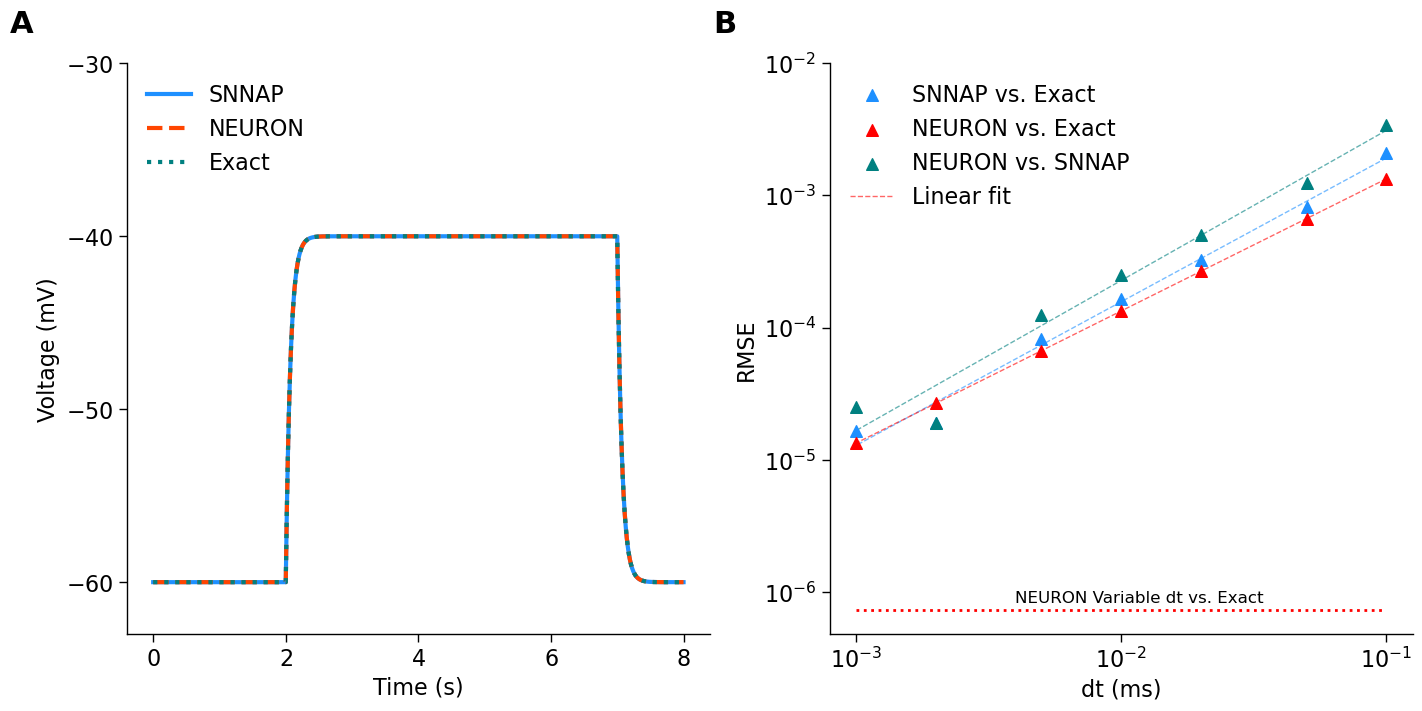

In [7]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14, 7),constrained_layout=True)

# Plot snnap, nrn, and exact solution together
t_snnap, v_snnap = get_v_snnap(0.1)
v_nrn,_ = get_v_nrn(t_snnap*1000,0.1)
v_an = get_v_an(t_snnap*1000, 2000, 7000, -60, 2, 0.1, 0.007)
ax1.plot(t_snnap,v_snnap,label="SNNAP",color="dodgerblue",linestyle="solid",linewidth=3)
ax1.plot(t_snnap,v_nrn,label="NEURON",color="orangered",linestyle="dashed",linewidth=3)
ax1.plot(t_snnap,v_an,label="Exact",color="teal",linestyle="dotted",linewidth=3)
ax1.legend(loc="upper left",frameon=False)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (mV)")
ax1.set_ylim((-63,-34))
remove_axes(ax1)
ax1.set_xticks([0,2,4,6,8])
ax1.set_yticks([-60,-50,-40,-30])

# Plot snnap, nrn, exact against each other for different epochs
x = np.log10(dt_list)
y_snnap = np.log10(err_analytical["snnap"])
y_nrn = np.log10(err_analytical["nrn"])
y_nrn_snnap = np.log10(err_nrn_snnap)
ax2.plot(x,linearfit(x,y_nrn_snnap),linestyle="dashed",color="teal",alpha=0.6,linewidth=1)
ax2.plot(x,linearfit(x,y_snnap),linestyle="dashed",color="dodgerblue",alpha=0.6,linewidth=1)
ax2.scatter(x,y_snnap,c="dodgerblue",s=70,zorder=2,marker="^",label='SNNAP vs. Exact')
remove_axes(ax2)
ax2.scatter(x,y_nrn,c="red",s=70,zorder=2,marker="^",label='NEURON vs. Exact')
ax2.scatter(x,y_nrn_snnap,c="teal",s=70,zorder=2,marker="^",label='NEURON vs. SNNAP')
ax2.plot(x,linearfit(x,y_nrn),linestyle="dashed",color="red",alpha=0.6,linewidth=1,label="Linear fit")
ax2.hlines([np.log10(err_var)],-3,-1,linestyle="dotted",color="red",linewidth=2)
ax2.text(-2.4, -6.1, "NEURON Variable dt vs. Exact", va='bottom', ha='left', color="black",fontsize=12)
ax2.set_xticks([-3,-2,-1],[r"$10^{-3}$",r"$10^{-2}$",r"$10^{-1}$"])
ax2.set_yticks([-2,-3,-4,-5,-6],[r"$10^{-2}$",r"$10^{-3}$",r"$10^{-4}$",r"$10^{-5}$",r"$10^{-6}$"])
ax2.legend(loc="upper left",frameon=False)
ax2.set_ylabel("RMSE", fontsize=16)
ax2.set_xlabel("dt (ms)", fontsize=16)

ax1.set_title("A", x=-0.2, y=1.08, ha='left', va='top', fontsize=22, fontweight='bold')
ax2.set_title("B", x=-0.2, y=1.08, ha='left', va='top', fontsize=22, fontweight='bold')

fig.savefig(os.path.join(figpath,f"{fig_prefix}_leak.jpg"),bbox_inches="tight",dpi=300)